<a href="https://colab.research.google.com/github/rajanaids-hub/BASICS-ML/blob/main/multivariate_linear_regression_hands_on.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multivariate Linear Regression — Hands-On Notebook
### Course: U23ADT306 – Basic Machine Learning Techniques (B.Tech AI & DS, Semester 3)

**Learning Objectives**
- Extend Linear Regression to MULTIPLE input features (multivariate case)
- Perform EDA on a multi-feature, real-world dataset with a mix of numeric and categorical columns
- Handle MISSING VALUES and encode CATEGORICAL features correctly
- Understand WHY feature scaling matters when features are on different scales
- Train and evaluate a multivariate Linear Regression model with scikit-learn
- Interpret multiple coefficients simultaneously

**Dataset:** California Housing Prices
**Source:** Widely known as the "California Housing Prices" dataset on Kaggle
(https://www.kaggle.com/datasets/camnugent/california-housing-prices), derived
from the 1990 U.S. Census. We download the same dataset from a public GitHub CSV
mirror (Aurelien Geron's "Hands-On Machine Learning" companion repository) so
every student gets identical data without needing a Kaggle account/API key.

10 columns -> 9 numeric features + 1 categorical feature (`ocean_proximity`)
Target -> `median_house_value`

**Estimated time:** 60–75 minutes


## 1. Environment Setup

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We install every library this notebook needs, so it runs identically
# on any machine (VS Code, Colab, or a fresh laptop).
# ------------------------------------------------------------------
import sys                      # sys -> gives access to the current Python interpreter path
import subprocess                # subprocess -> lets us call pip install from inside Python

required_packages = [
    "pandas",        # tabular data handling
    "numpy",         # numerical arrays and linear algebra
    "scikit-learn",  # model, preprocessing, metrics
    "matplotlib",    # plotting
    "seaborn"        # statistical plots (heatmaps, pairplots)
]

for package in required_packages:
    # --break-system-packages keeps this working even on locked-down system Python installs
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--break-system-packages", package])

print("All required packages are installed.")


All required packages are installed.


## 2. Dataset Download + Loading
We download the California Housing Prices CSV directly from a public GitHub mirror.

If your machine has the Kaggle CLI configured, you could alternatively run:
```
# import kagglehub
# path = kagglehub.dataset_download("camnugent/california-housing-prices")
```


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We need the raw data in memory before we can explore or model it. We
# download a real-world CSV directly from a public URL so every student
# gets the exact same data with zero manual upload or login required.
# ------------------------------------------------------------------
import pandas as pd   # pandas -> library for reading CSV files into DataFrames

# Public raw-CSV mirror of the California Housing Prices dataset
DATA_URL = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"

housing_df = pd.read_csv(DATA_URL)   # download and parse the CSV directly into a DataFrame

# Display first 5 rows to sanity-check column names and values
housing_df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Exploratory Data Analysis (EDA)

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We check dataset size and column data types before doing anything else.
# ------------------------------------------------------------------
print("Shape of dataset (rows, columns):", housing_df.shape)   # (num_samples, num_features + target)
print()
print("Data types of each column:")
print(housing_df.dtypes)   # 'ocean_proximity' shows as 'object' (text) -- this is our categorical column


Shape of dataset (rows, columns): (20640, 10)

Data types of each column:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Missing values can break model training. We must find and quantify them
# before deciding how to handle them (this dataset has some real missing
# values in 'total_bedrooms', typical of real-world data).
# ------------------------------------------------------------------
missing_per_column = housing_df.isnull().sum()   # count NaNs per column
print("Missing values per column:")
print(missing_per_column[missing_per_column > 0])   # show only columns that actually have missing values


Missing values per column:
total_bedrooms    207
dtype: int64


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Summary statistics reveal SCALE differences between features (e.g.
# 'population' is in the thousands, while 'median_income' is a small
# decimal). This is exactly why feature scaling will be necessary later.
# ------------------------------------------------------------------
housing_df.describe()   # count, mean, std, min, quartiles, max per numeric column


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


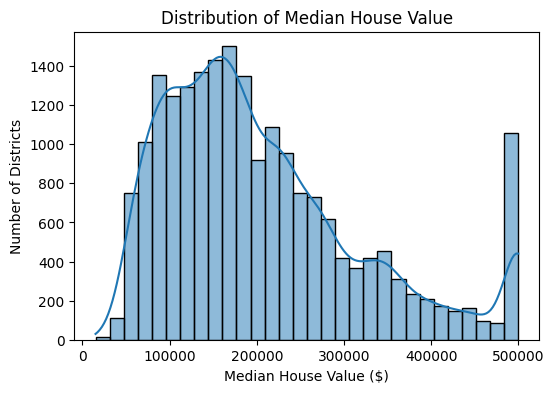

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Visualization #1: Distribution of the TARGET variable.
# Understanding its shape helps judge whether Linear Regression's
# assumption of a roughly continuous target is reasonable here.
# ------------------------------------------------------------------
import matplotlib.pyplot as plt   # core plotting library
import seaborn as sns             # statistical plotting on top of matplotlib

plt.figure(figsize=(6, 4))
sns.histplot(housing_df["median_house_value"], bins=30, kde=True)   # bins=30 -> finer detail given wide value range
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value ($)")
plt.ylabel("Number of Districts")
plt.show()

# WHAT TO OBSERVE: Notice the spike near $500,000 -- this is a known
# artifact where house values were capped at $500,000 during collection.


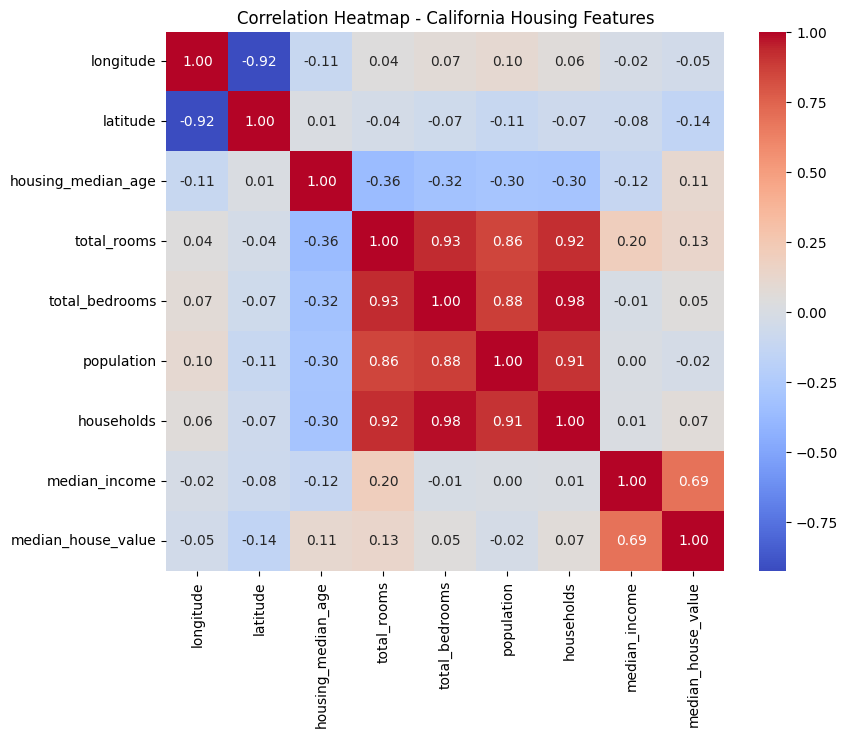

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Visualization #2: Correlation heatmap across all NUMERIC features + target.
# In multivariate regression we must understand how EACH feature relates
# to the target, and whether features are correlated with EACH OTHER
# (multicollinearity), which can make coefficients unstable/hard to interpret.
# ------------------------------------------------------------------
numeric_df = housing_df.select_dtypes(include=["float64", "int64"])   # drop the text column for correlation

plt.figure(figsize=(9, 7))
correlation_matrix = numeric_df.corr()                                # pairwise correlation, -1 to 1
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")  # fmt=".2f" -> round labels to 2 decimals
plt.title("Correlation Heatmap - California Housing Features")
plt.show()

# WHAT TO OBSERVE: 'median_income' has by far the strongest positive
# correlation with 'median_house_value'. 'total_rooms', 'total_bedrooms',
# 'population', and 'households' are all strongly correlated WITH EACH
# OTHER -- a sign of multicollinearity to keep in mind when interpreting coefficients.


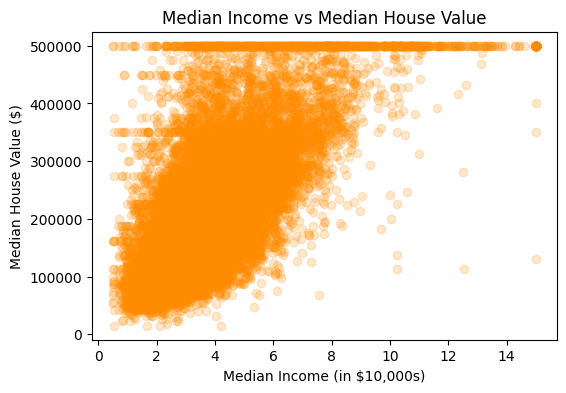

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Visualization #3: Scatter plot between the strongest predictor
# (median_income) and the target, to visually confirm a linear trend.
# ------------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(housing_df["median_income"], housing_df["median_house_value"], alpha=0.2, color="darkorange")
# alpha=0.2 -> partial transparency so overlapping points (dense areas) show as darker patches
plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income (in $10,000s)")
plt.ylabel("Median House Value ($)")
plt.show()

# WHAT TO OBSERVE: A clear upward trend confirms income is a strong linear
# predictor of house value. The flat line of points at the top is the
# same $500,000 cap visible in the histogram above.


## 4. Data Preprocessing
This dataset needs THREE preprocessing steps beyond the simple regression case:
missing-value handling, categorical encoding, and feature scaling.


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# 'total_bedrooms' has missing values (seen in Section 3). We fill (impute)
# them with the column MEDIAN rather than dropping rows, so we don't lose
# valuable data from otherwise-complete records.
# ------------------------------------------------------------------
median_bedrooms = housing_df["total_bedrooms"].median()          # compute the median of the non-missing values
housing_df["total_bedrooms"] = housing_df["total_bedrooms"].fillna(median_bedrooms)
# fillna() -> replaces every NaN in this column with the median we just computed

print("Remaining missing values in 'total_bedrooms':", housing_df["total_bedrooms"].isnull().sum())
# should now print 0 -- confirms imputation worked


Remaining missing values in 'total_bedrooms': 0


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# 'ocean_proximity' is categorical (text) data, but Linear Regression only
# understands numbers. One-Hot Encoding converts each category into its
# own 0/1 column, avoiding a false sense of numeric order between categories.
# ------------------------------------------------------------------
print("Unique categories in 'ocean_proximity':", housing_df["ocean_proximity"].unique())

# pd.get_dummies -> creates one binary column per category
# drop_first=True -> drops one category to avoid the "dummy variable trap"
# (perfect multicollinearity between the one-hot columns)
housing_encoded_df = pd.get_dummies(housing_df, columns=["ocean_proximity"], drop_first=True)

housing_encoded_df.head()   # confirm new binary columns like 'ocean_proximity_INLAND' now exist


Unique categories in 'ocean_proximity': <StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We separate the DataFrame into X (all input features) and y (the target
# we want to predict), which is required before any scikit-learn model
# can be trained.
# ------------------------------------------------------------------
target_column = "median_house_value"                                    # the column we want to predict
feature_columns = [col for col in housing_encoded_df.columns if col != target_column]
# list comprehension -> every column EXCEPT the target becomes an input feature

X = housing_encoded_df[feature_columns]   # X -> DataFrame of input features (multivariate!)
y = housing_encoded_df[target_column]     # y -> Series of target values (median house value)

print("X shape:", X.shape)   # expect (20640, 13) -> original 8 numeric features + 5 one-hot encoded columns
print("y shape:", y.shape)   # expect (20640,)


X shape: (20640, 12)
y shape: (20640,)


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We split into train/test sets BEFORE scaling, so that information from
# the test set never "leaks" into how we compute scaling parameters
# (a common real-world mistake to avoid).
# ------------------------------------------------------------------
from sklearn.model_selection import train_test_split

# test_size=0.2 -> 80% train / 20% test split
# random_state=42 -> makes the split reproducible across runs
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 16512
Testing samples: 4128


In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# StandardScaler rescales every feature to have mean=0 and std=1. This
# matters because features like 'population' (range: hundreds to
# thousands) would otherwise dominate features like 'median_income'
# (range: roughly 0-15) purely due to numeric scale, even if both are
# equally predictive.
# ------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()                        # create the scaler object
X_train_scaled = scaler.fit_transform(X_train)   # fit_transform -> LEARN mean/std from train data, then scale it
X_test_scaled = scaler.transform(X_test)         # transform ONLY -> reuse train-set mean/std on test data
# IMPORTANT: We never call fit() on the test set -- that would leak test-set
# statistics into preprocessing, giving an overly optimistic evaluation.

print("Mean of each scaled training feature (should be ~0):")
print(X_train_scaled.mean(axis=0).round(2))   # axis=0 -> average down each column (each feature)


Mean of each scaled training feature (should be ~0):
[ 0.  0. -0.  0. -0.  0. -0. -0. -0. -0. -0. -0.]


## 5. Model Building

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We train scikit-learn's LinearRegression on the SCALED multivariate
# features. With multiple features, the model learns one coefficient per
# feature plus a single intercept: y = b0 + b1*x1 + b2*x2 + ... + bn*xn
# ------------------------------------------------------------------
from sklearn.linear_model import LinearRegression

multivariate_model = LinearRegression()          # create the (untrained) model
multivariate_model.fit(X_train_scaled, y_train)  # learn coefficients from scaled training data

# Pair each feature name with its learned coefficient for readability
coefficients_df = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": multivariate_model.coef_
}).sort_values(by="Coefficient", ascending=False)   # sort so most influential features appear first

print("Intercept (b0):", round(multivariate_model.intercept_, 2))
print()
print(coefficients_df)


Intercept (b0): 207194.69

                       Feature   Coefficient
7                median_income  75167.774766
4               total_bedrooms  43068.181842
6                   households  18382.196324
2           housing_median_age  13889.866189
9       ocean_proximity_ISLAND   2118.437572
11  ocean_proximity_NEAR OCEAN   1139.905592
10    ocean_proximity_NEAR BAY  -1621.705018
3                  total_rooms -13094.251162
8       ocean_proximity_INLAND -18506.095225
5                   population -43403.432427
0                    longitude -53826.648016
1                     latitude -54415.696144


## 6. Evaluation

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We evaluate how well the trained model predicts house values on the
# UNSEEN, scaled test set, using three standard regression metrics.
# ------------------------------------------------------------------
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np   # needed for sqrt() below

y_pred = multivariate_model.predict(X_test_scaled)   # generate predictions on the scaled test features

r2 = r2_score(y_test, y_pred)                          # 1.0 = perfect prediction; 0 = no better than the mean
mae = mean_absolute_error(y_test, y_pred)              # average absolute dollar error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))     # penalizes large errors more than MAE

print(f"R^2 Score : {r2:.4f}  (values around 0.60-0.65 are typical/expected for plain Linear Regression here)")
print(f"MAE       : ${mae:,.2f}  (average dollar error per prediction)")
print(f"RMSE      : ${rmse:,.2f}  (larger errors are penalized more heavily here)")


R^2 Score : 0.6254  (values around 0.60-0.65 are typical/expected for plain Linear Regression here)
MAE       : $50,670.74  (average dollar error per prediction)
RMSE      : $70,060.52  (larger errors are penalized more heavily here)


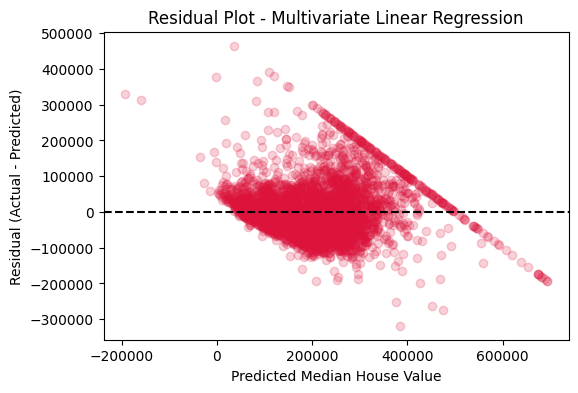

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Residual plot: checks whether prediction errors are randomly scattered
# (good) or show a clear pattern (would suggest missing non-linear terms --
# expected here since Linear Regression is a simple baseline model).
# ------------------------------------------------------------------
residuals = y_test - y_pred   # actual minus predicted, per test sample

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.2, color="crimson")
plt.axhline(y=0, color="black", linestyle="--")   # reference line at zero error
plt.title("Residual Plot - Multivariate Linear Regression")
plt.xlabel("Predicted Median House Value")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

# WHAT TO OBSERVE: A funnel shape and a diagonal band near the $500,000 cap
# are visible -- both stem from the dataset's known price cap and confirm
# plain Linear Regression is a useful but imperfect baseline model.


## 7. Interpretation

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# Because features were scaled, coefficients are now directly comparable
# to each other in terms of RELATIVE importance (larger magnitude = bigger
# influence on price per one standard-deviation change in that feature).
# ------------------------------------------------------------------
top_positive = coefficients_df.iloc[0]   # feature with the strongest positive effect on price
top_negative = coefficients_df.iloc[-1]  # feature with the strongest negative effect on price

print("Plain-English interpretation:")
print(f"- '{top_positive['Feature']}' has the strongest POSITIVE effect on predicted house value "
      f"(coefficient = {top_positive['Coefficient']:.2f}).")
print(f"- '{top_negative['Feature']}' has the strongest NEGATIVE effect on predicted house value "
      f"(coefficient = {top_negative['Coefficient']:.2f}).")
print("- Because all numeric features were scaled to the same range, we can directly")
print("  compare the SIZE of these coefficients to judge relative feature importance.")


Plain-English interpretation:
- 'median_income' has the strongest POSITIVE effect on predicted house value (coefficient = 75167.77).
- 'latitude' has the strongest NEGATIVE effect on predicted house value (coefficient = -54415.70).
- Because all numeric features were scaled to the same range, we can directly
  compare the SIZE of these coefficients to judge relative feature importance.


## 8. Practice Exercises (No Answers Provided)
1. Try imputing `total_bedrooms` with the MEAN instead of the MEDIAN. Does R² change noticeably?
2. Drop the one-hot encoded `ocean_proximity` columns and retrain. Does location category matter for price?
3. Engineer a new feature `rooms_per_household = total_rooms / households` and see if it improves R².
4. Compute the correlation between `total_rooms` and `households`. Given the earlier heatmap, is multicollinearity a real concern here?
5. Try Ridge or Lasso regression (`sklearn.linear_model.Ridge` / `Lasso`) and compare R² against plain Linear Regression.


## 9. Summary / Key Takeaways

In [ ]:
# ------------------------------------------------------------------
# WHY THIS CELL EXISTS:
# We record the exact library versions used, so results can be reproduced
# on any other machine before this notebook is pushed to GitHub.
# ------------------------------------------------------------------
import sklearn

print("Library versions used in this notebook:")
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("scikit-learn :", sklearn.__version__)
print("matplotlib   :", plt.matplotlib.__version__)
print("seaborn      :", sns.__version__)


Library versions used in this notebook:
pandas       : 3.0.2
numpy        : 2.4.4
scikit-learn : 1.8.0
matplotlib   : 3.10.8
seaborn      : 0.13.2


**Key Takeaways**
- Multivariate Linear Regression extends the same idea as simple Linear Regression to MANY input features at once, some numeric and some categorical.
- Missing values must be handled (e.g. median imputation) before training.
- Categorical features must be encoded numerically (e.g. one-hot encoding) — Linear Regression cannot use raw text.
- Feature scaling (e.g. `StandardScaler`) is essential when features have very different numeric ranges.
- Always `fit` the scaler on training data only, and `transform` (never `fit`) the test data, to avoid data leakage.
- Correlation heatmaps help detect multicollinearity between features, which can make coefficients less stable/interpretable.
